In [1]:
#!/bin/env python3

import os, re
import bids
from nilearn import image as nimg
from nilearn import plotting as nplot
from nilearn.plotting import plot_design_matrix
import nilearn.glm.first_level
import pandas as pd
import numpy as np
import logging
import argparse
import glob

In [14]:
import os
import boto3
from botocore import UNSIGNED
from botocore.config import Config


sub=10 ##input subject number 1-10#
ses=3 ##input ses number 1-6#

# 1. Ensure the output directory exists
output_dir = f'ds006598-download/sub-PAN{sub}/ses-{ses}/func'
os.makedirs(output_dir, exist_ok=True)

# 2. Initialize the S3 client for public access
s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))

# 3. Define bucket, key, and local path
bucket_name = 'openneuro.org'
s3_key = f'ds006598/sub-PAN{sub}/ses-{ses}/func/sub-PAN{sub}_ses-{ses}_task-epiproj_space-MNI152NLin6Asym_res-2_desc-preproc_bold.nii.gz'
local_file = os.path.join(output_dir, f'sub-PAN{sub}_ses-{ses}_task-epiproj_space-MNI152NLin6Asym_res-2_desc-preproc_bold.nii.gz')

# 4. Download
print(f"Downloading {local_file}...")
s3.download_file(bucket_name, s3_key, local_file)
print("Download complete.")

Download complete.


In [15]:
#set your paths
basedir = os.path.join("/home/jovyan/panmvpa")
funcdir = os.path.join(basedir, "notebooks/ds006598-download/sub-PAN%2i/ses-%i/func" %(sub, ses))
func_files = glob.glob(os.path.join(funcdir,'*ses-%i_task-epiproj*.nii.gz' %(ses)))
func_files

['/home/jovyan/panmvpa/notebooks/ds006598-download/sub-PAN10/ses-3/func/sub-PAN10_ses-3_task-epiproj_space-MNI152NLin6Asym_res-2_desc-preproc_bold.nii.gz']

In [16]:
#append data for fixed effects model
design_matrices = []
fmri_img = []
func_tr = 1.355

In [17]:
func_img = nimg.load_img(func_files)
fmri_img.append(func_img)

In [18]:
#read fmri volumes in seconds
frame_times = np.arange(func_img.shape[-1]) * func_tr

In [19]:
stimdir = os.path.join(basedir, "ds006598-download/derivatives/afni_timing_epiproj")
eventsfile = os.path.join(stimdir,'PAN%2i_ses-%i_epiproj_3col.txt' %(sub, ses))
events = pd.read_table(eventsfile)
print(events)

    onset  duration trial_type
0      17        10    trial 1
1      37        10    trial 2
2      57        10    trial 3
3      77        10    trial 4
4      97        10    trial 5
5     117        10    trial 6
6     137        10    trial 7
7     157        10    trial 8
8     177        10    trial 9
9     197        10   trial 10
10    217        10   trial 11
11    237        10   trial 12
12    257        10   trial 13
13    277        10   trial 14
14    297        10   trial 15
15    317        10   trial 16
16    337        10   trial 17
17    357        10   trial 18
18    377        10   trial 19
19    397        10   trial 20
20    417        10   trial 21
21    437        10   trial 22
22    457        10   trial 23
23    477        10   trial 24
24    497        10   trial 25
25    517        10   trial 26
26    537        10   trial 27
27    557        10   trial 28
28    577        10   trial 29
29    597        10   trial 30


In [20]:
design = nilearn.glm.first_level.make_first_level_design_matrix(frame_times, events,drift_model=None,high_pass=0.01,hrf_model='spm')
design_matrices.append(design)

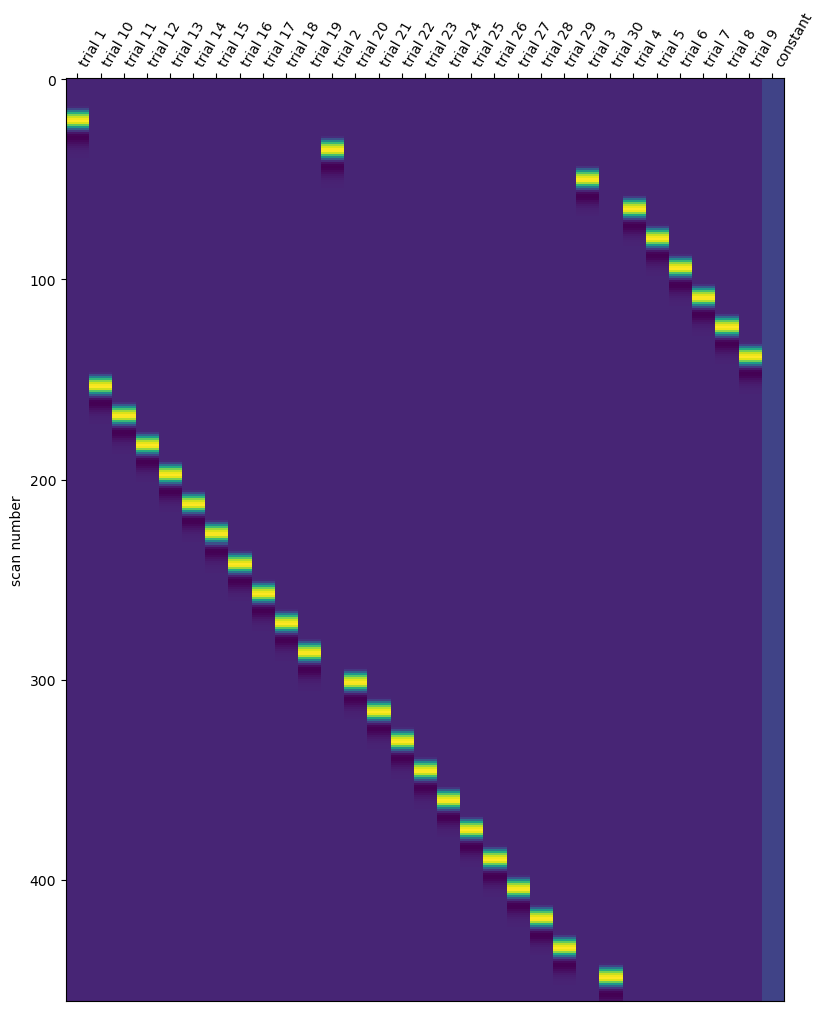

In [21]:
designplot = plot_design_matrix(design_matrices)
#design.to_csv(os.path.join(stimdir,"PAN01_ses1_epiproj_design.csv"))

In [22]:
#setup basic contrasts
contrast_matrix = np.eye(design.shape[1])
basic_contrasts = dict([(column, contrast_matrix[i]) for i, column in enumerate(design.columns)])

In [ ]:
fmri_glm = nilearn.glm.first_level.FirstLevelModel(n_jobs=8,smoothing_fwhm=4, t_r=func_tr)
fmri_glm = fmri_glm.fit(fmri_img,design_matrices=design_matrices)
report = fmri_glm.generate_report(basic_contrasts)
outdir=os.path.join(basedir,'task_glm','PAN%2i_epiproj_trialev_ses-%i' %(sub, ses))
os.makedirs(outdir, exist_ok=True)
report.save_as_html(os.path.join(outdir,'PAN%2i_epiproj_trialev_ses-%i_report.html' %(sub, ses)))

/tmp/ipykernel_98/2972586114.py:2: UserWarning: If design matrices are supplied, [t_r] will be ignored.
  fmri_glm = fmri_glm.fit(fmri_img,design_matrices=design_matrices)


In [ ]:
##saves contrasts to nii files and generates plots#
bg_img = nimg.mean_img(fmri_img)
for index, (contrast_id, contrast_val) in enumerate(basic_contrasts.items()):
    #print('  Contrast % 2i out of %i: %s' % (index + 1, len(basic_contrasts), contrast_id))
    betamap = fmri_glm.compute_contrast(contrast_val, output_type='effect_size')
    # write the resulting stat images to file
    beta_image_path = os.path.join(outdir, 'PAN%2i_ses-%s_epiproj_%s_beta.nii.gz' % (sub, ses, contrast_id))
    betamap.to_filename(beta_image_path)
#displaying takes up a lot of RAM
    #display = nplot.plot_stat_map(beta_map, bg_img=bg_img, title="%s" % (contrast_id,), display_mode='z', cut_coords=3, black_bg=True)
    #display.savefig(os.path.join(outdir,"%s_%s.png" % (task,contrast_id,)))